# Simulation run from config file
This jupyter notebook aims to run a full configuration and show all the features regarding simulation. 

## Imports and generation

In [1]:
import os

from vote_simulation.simulation.simulation import simulation_series_from_config

print(os.getcwd())


results = simulation_series_from_config("config.toml", reload=True)

/home/ambraser/Desktop/Stage/Code/voteSim/vote_simulation/demo/simulation


Running simulation series:   0%|          | 0/4 [00:00<?, ?it/s]

Running simulation: UNI · 1000 voters · 14 cand. × 1000 iterations with 4 rules


Running simulation series:  25%|██▌       | 1/4 [00:03<00:10,  3.50s/it]

Simulation completed — cached to /home/ambraser/Desktop/Stage/Code/voteSim/vote_simulation/demo/data/results/UNI_v1000_c14_i1000.parquet
Running simulation: EUCLID_1D · 1000 voters · 14 cand. × 1000 iterations with 4 rules


...

Simulation completed — cached to /home/ambraser/Desktop/Stage/Code/voteSim/vote_simulation/demo/data/results/EUCLID_1D_v1000_c14_i1000.parquet
Running simulation: EUCLID_2D · 1000 voters · 14 cand. × 1000 iterations with 4 rules


Running simulation series:  75%|███████▌  | 3/4 [00:10<00:03,  3.35s/it]

Simulation completed — cached to /home/ambraser/Desktop/Stage/Code/voteSim/vote_simulation/demo/data/results/EUCLID_2D_v1000_c14_i1000.parquet
Running simulation: IC · 1000 voters · 14 cand. × 1000 iterations with 4 rules


Running simulation series: 100%|██████████| 4/4 [00:13<00:00,  3.36s/it]

Simulation completed — cached to /home/ambraser/Desktop/Stage/Code/voteSim/vote_simulation/demo/data/results/IC_v1000_c14_i1000.parquet
Completed 4 simulation series.


## Metrics

gen_model  n_voters  n_candidates  step_count  n_iterations  mean_distance most_distant_rule_a most_distant_rule_b  most_distant_distance
EUCLID_1D      1000            14        1000          1000      10.058333                COPE              AP_T05              20.116667
EUCLID_2D      1000            14        1000          1000       4.566667                COPE              AP_T05               9.133333
       IC      1000            14        1000          1000      24.460833                COPE              AP_T05              48.921665
      UNI      1000            14        1000          1000      25.495832                COPE              AP_T05              50.991665


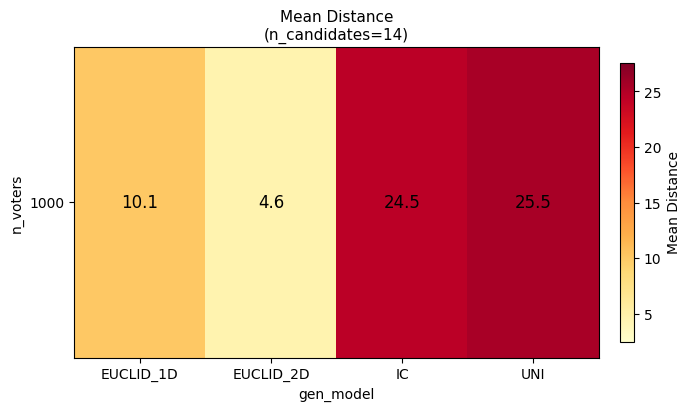

<Axes: title={'center': 'Mean Distance\n(n_candidates=14)'}, xlabel='gen_model', ylabel='n_voters'>

In [2]:
df = results.summary_frame()
print(df.to_string(index=False))

results.filter(gen_model="EUCLID_2D").metric_matrix()

results.plot_metric_heatmap(col_param="gen_model", row_param="n_voters", show=True)

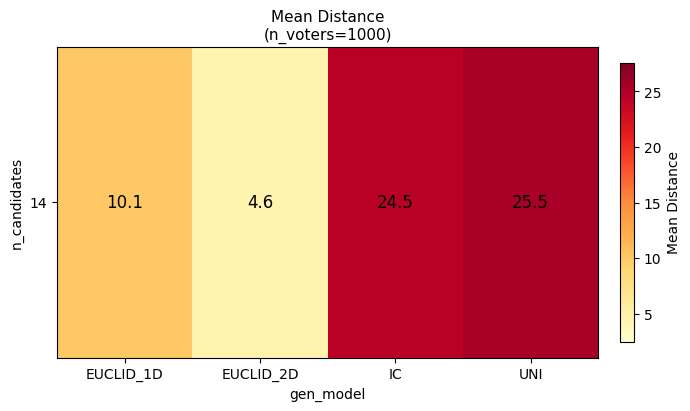

<Axes: title={'center': 'Mean Distance\n(n_voters=1000)'}, xlabel='gen_model', ylabel='n_candidates'>

In [13]:
# Impact of generation model

results.plot_metric_heatmap(col_param="gen_model", row_param="n_candidates", show=True)

## Filtering
As we discussed the model has to be able to "filter" to allow the study of the impact of one parameter

### Filter on number of candidates

gen_model  n_voters  n_candidates  step_count  n_iterations  mean_distance most_distant_rule_a most_distant_rule_b  most_distant_distance
EUCLID_1D      1000            14        1000          1000      10.058333                COPE              AP_T05              20.116667
EUCLID_2D      1000            14        1000          1000       4.566667                COPE              AP_T05               9.133333
       IC      1000            14        1000          1000      24.460833                COPE              AP_T05              48.921665
      UNI      1000            14        1000          1000      25.495832                COPE              AP_T05              50.991665


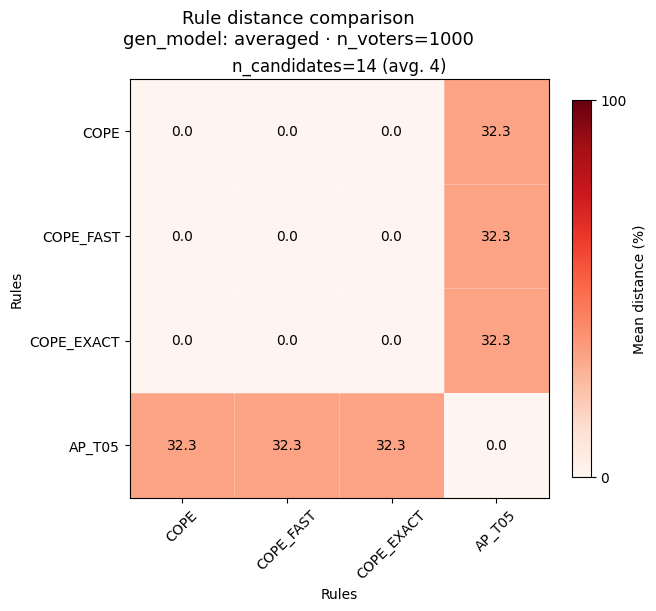

[<Axes: title={'center': 'n_candidates=14 (avg. 4)'}, xlabel='Rules', ylabel='Rules'>]

In [3]:
results_c14 = results.filter(n_candidates=14)
df_c14 = results_c14.summary_frame()
print(df_c14.to_string(index=False))

results.filter(n_candidates=14).plot_comparison_grid(show=True)

## Details of a serie 

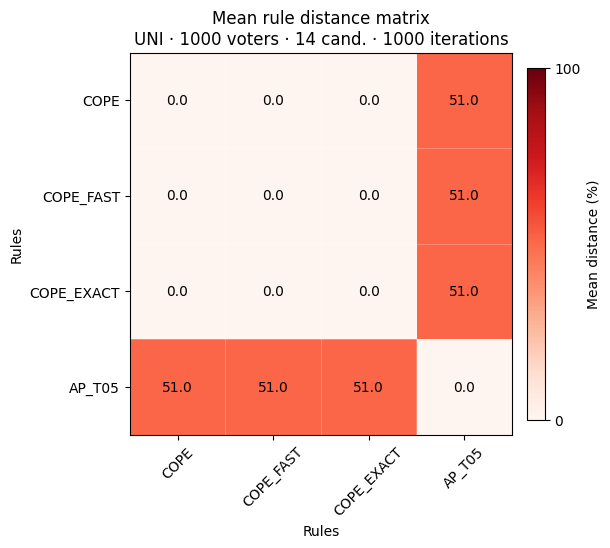

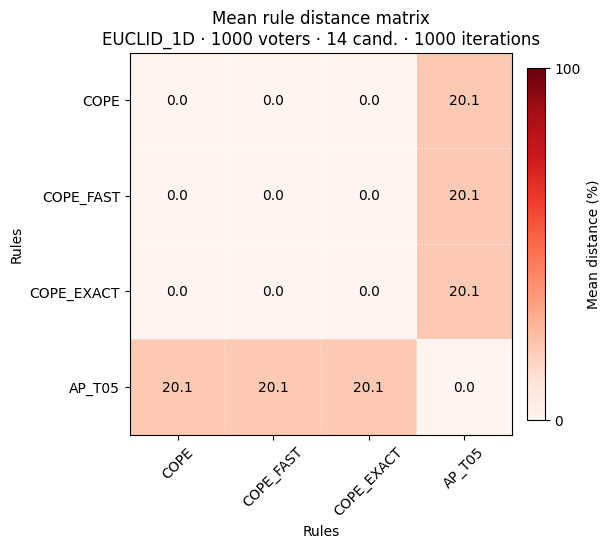

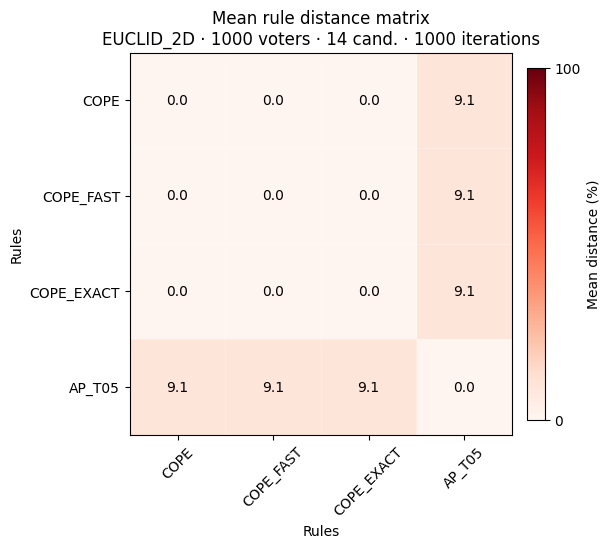

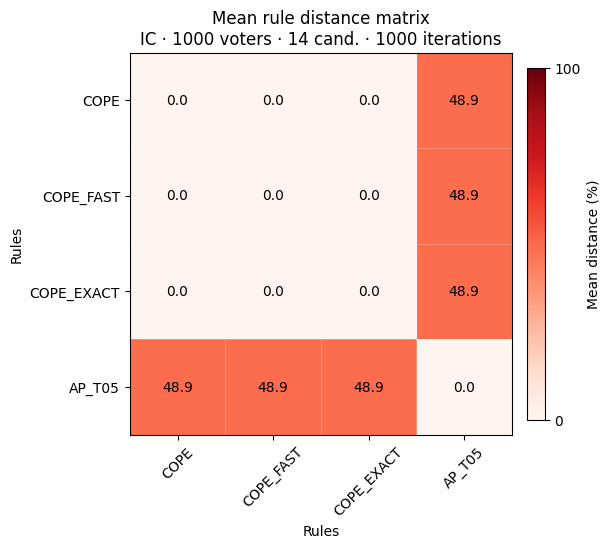

<Axes: title={'center': 'Mean rule distance matrix\nIC · 1000 voters · 14 cand. · 1000 iterations'}, xlabel='Rules', ylabel='Rules'>

In [14]:
# series = results.get_series("UNI",900, 14)
series = results.get_series("UNI", 1000, 14)


series.plot_mean_distance_matrix(show=True)

results.get_series("EUCLID_1D", 1000, 14).plot_mean_distance_matrix(show=True)

results.get_series("EUCLID_2D", 1000, 14).plot_mean_distance_matrix(show=True)


results.get_series("IC", 1000, 14).plot_mean_distance_matrix(show=True)

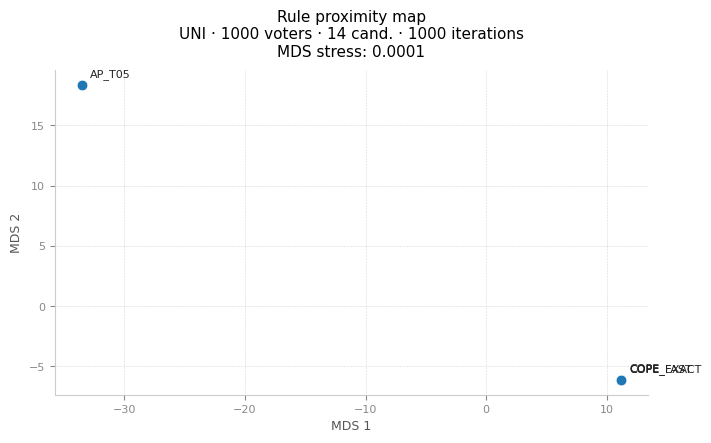

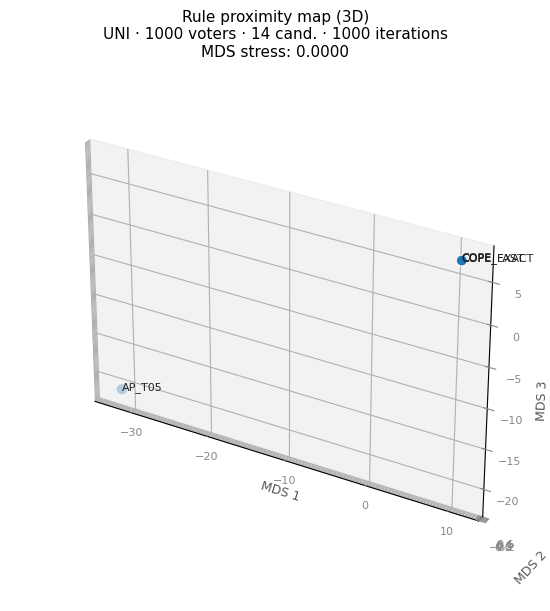

<Axes3D: title={'center': 'Rule proximity map (3D)\nUNI · 1000 voters · 14 cand. · 1000 iterations\nMDS stress: 0.0000'}, xlabel='MDS 1', ylabel='MDS 2', zlabel='MDS 3'>

In [11]:
series.plot_rules_2d(show=True)

series.plot_rules_3d(show=True)

# Metrics

In [12]:
results.filter(gen_model="IC").metric_matrix()

(n_candidates         14
 n_voters               
 1000          24.460833,
 'gen_model=IC')